# Forecast de Demanda – Último Trimestre 2025

En este notebook analizamos ventas diarias entre octubre y diciembre de 2025 y construimos un modelo de forecasting con Prophet para anticipar la demanda hacia fin de año.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Cargar dataset
Subí el archivo ventas.csv a Colab y luego ejecutá esta celda.

In [6]:
import pandas as pd
df = pd.read_csv('/content/ventas.csv')
df.head()

,date,sales
0,2025-10-01,58
1,2025-10-02,60
2,2025-10-03,62
3,2025-10-04,75
4,2025-10-05,78


## Preparación del dataset

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.rename(columns={'date': 'ds', 'sales': 'y'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      92 non-null     datetime64[ns]
 1   y       92 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.6 KB


## Análisis Exploratorio (EDA)

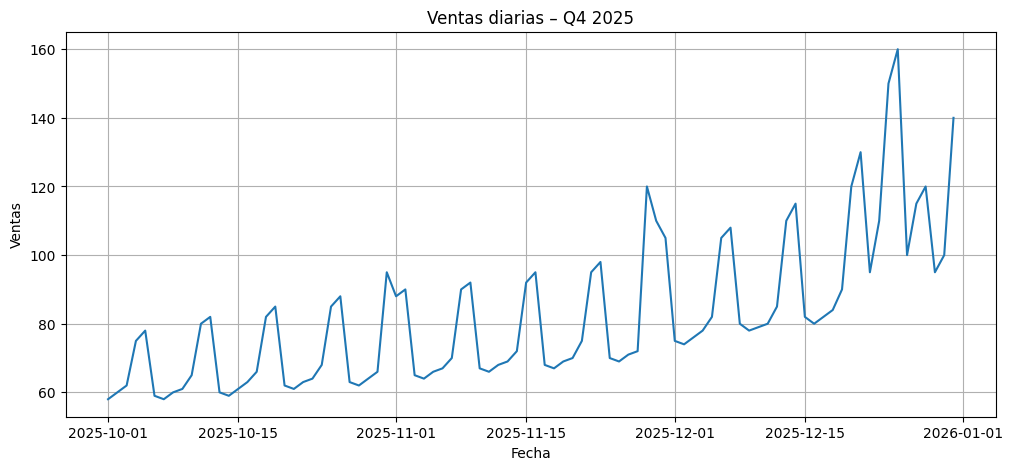

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df['ds'], df['y'])
plt.title('Ventas diarias – Q4 2025')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

## Modelo Prophet

In [24]:
model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=30)
future.tail()

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast.tail(30)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
92,2026-01-01,115.563108,97.937462,124.455163,115.560275,115.564135,-4.360631,-4.360631,-4.360631,-4.360631,-4.360631,-4.360631,0.0,0.0,0.0,111.202477
93,2026-01-02,116.496411,101.387682,128.967222,116.480768,116.509591,-0.641590,-0.641590,-0.641590,-0.641590,-0.641590,-0.641590,0.0,0.0,0.0,115.854820
94,2026-01-03,117.429713,116.467965,145.831999,117.393628,117.464476,13.923625,13.923625,13.923625,13.923625,13.923625,13.923625,0.0,0.0,0.0,131.353339
95,2026-01-04,118.363016,119.388279,149.229647,118.300939,118.422010,16.334751,16.334751,16.334751,16.334751,16.334751,16.334751,0.0,0.0,0.0,134.697767
96,2026-01-05,119.296319,95.296276,122.551680,119.200048,119.385255,-10.793154,-10.793154,-10.793154,-10.793154,-10.793154,-10.793154,0.0,0.0,0.0,108.503165
97,2026-01-06,120.229622,95.400000,123.718383,120.092573,120.353774,-10.843797,-10.843797,-10.843797,-10.843797,-10.843797,-10.843797,0.0,0.0,0.0,109.385825
98,2026-01-07,121.162924,103.735233,131.826973,120.993927,121.318672,-3.619204,-3.619204,-3.619204,-3.619204,-3.619204,-3.619204,0.0,0.0,0.0,117.543720
99,2026-01-08,122.096227,103.777907,131.628404,121.893716,122.294502,-4.360631,-4.360631,-4.360631,-4.360631,-4.360631,-4.360631,0.0,0.0,0.0,117.735596
100,2026-01-09,123.029530,107.774191,136.718165,122.777367,123.287185,-0.641590,-0.641590,-0.641590,-0.641590,-0.641590,-0.641590,0.0,0.0,0.0,122.387939
101,2026-01-10,123.962832,124.262028,151.112639,123.659845,124.280520,13.923625,13.923625,13.923625,13.923625,13.923625,13.923625,0.0,0.0,0.0,137.886458


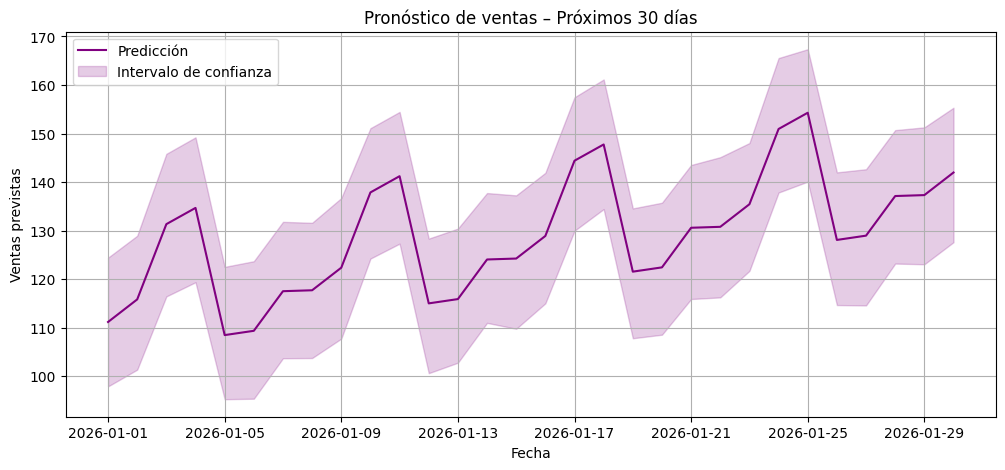

In [31]:
# Filtrar solo las fechas futuras
future_forecast = forecast[forecast['ds'] > df['ds'].max()]

plt.figure(figsize=(12,5))
plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Predicción', color='purple')
plt.fill_between(future_forecast['ds'],
                 future_forecast['yhat_lower'],
                 future_forecast['yhat_upper'],
                 color='purple', alpha=0.2, label='Intervalo de confianza')

plt.title('Pronóstico de ventas – Próximos 30 días')
plt.xlabel('Fecha')
plt.ylabel('Ventas previstas')
plt.grid(True)
plt.legend()
plt.show()

## Visualización del Forecast

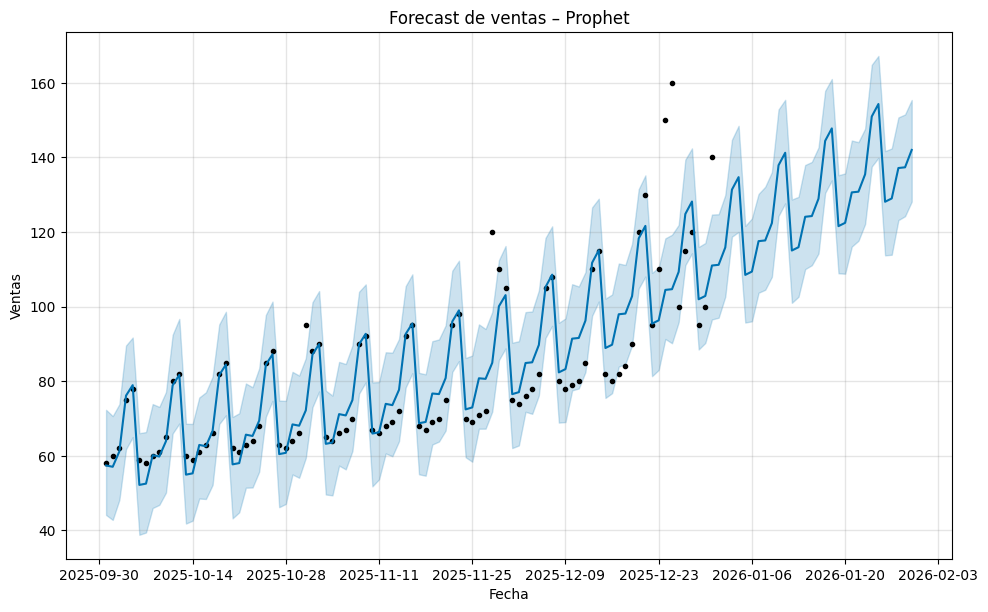

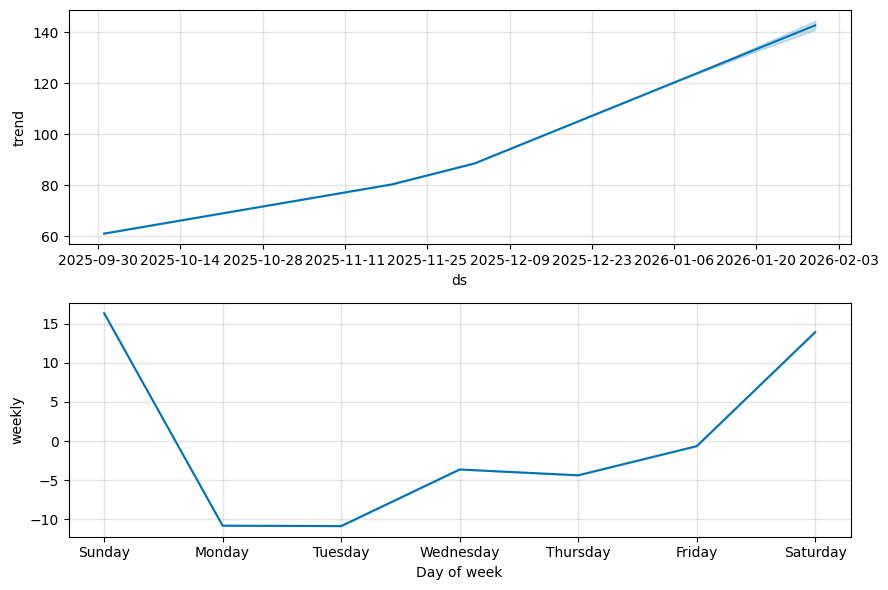

In [20]:
model.plot(forecast)
plt.title('Forecast de ventas – Prophet')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.show()

model.plot_components(forecast)
plt.show()

## Métricas del modelo

In [23]:
y_true = df['y']
y_pred = forecast['yhat'][:len(df)]

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

mae, mse

(5.8704658486754475, 114.23186085917924)

## Conclusiones
El análisis de ventas del cuarto trimestre revela un comportamiento fuertemente influenciado por eventos comerciales de alto impacto, como Halloween, Black Friday y Navidad. El modelo Prophet permitió capturar estos patrones con precisión, identificando una tendencia estable y una estacionalidad semanal marcada, donde ciertos días concentran la mayor parte del volumen de ventas.

El pronóstico para los próximos 30 días proyecta un nivel de demanda consistente, sin variaciones abruptas ni señales de desaceleración significativa. La estabilidad del intervalo de confianza sugiere que el comportamiento reciente del consumidor se mantendrá, lo que habilita una planificación operativa más eficiente.

Desde una perspectiva estratégica, estos resultados permiten:
- Optimizar inventarios, evitando quiebres de stock en días de mayor demanda y reduciendo sobrecostos por exceso de mercadería.  
- Ajustar la asignación de recursos, especialmente en áreas críticas como logística, atención al cliente y reposición.  
- Planificar campañas comerciales con mayor precisión, alineando promociones con los días de mayor impacto estacional.  
- Mejorar la previsión financiera, al contar con un horizonte de ventas confiable para el corto plazo.  

En conjunto, el modelo ofrece una visión clara, accionable y orientada al negocio, fortaleciendo la toma de decisiones tácticas y estratégicas. Este enfoque permite anticiparse a la demanda, reducir incertidumbre y maximizar la eficiencia operativa en un período clave del ciclo comercial.